In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers,Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization
import os
import cv2 as cv

C:\Users\ARBAJ\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
path=r"C:\Users\ARBAJ\FSA_MACHINE_LEARNING\archive (10)\tomato\train"


In [4]:
dis=os.listdir(path)
dis

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___healthy',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']

In [6]:
dis.index('Tomato___healthy')

2

In [ ]:
Data=[]
for i in dis:# ALL FOLDERS INSIDE PARENT PATH
    #print(i)
    A=os.path.join(path,i) #FOR JOINING PATHS
    #print(A)
    
    
    
    for j in os.listdir(A):# FOR GETTING ALL CONTENT FROM FOLDER
        #print(j)
        B=os.path.join(A,j)#JOIN
        #print(B)
        img=cv.imread(B)#CONVERTING IMAGE TO PIXEL INTENSITY MATRIX
        C=cv.resize(img,(150,150))# RESIZING PIXEL INTENSITY MATRIX
        T=dis.index(i) #FOR GETTING TARGET VARIABLE
        Data.append([C,T]) #TO STORE    

In [14]:
Data=[]
for i in dis:
    
    A=os.path.join(path,i)
    for j in os.listdir(A):
        B=os.path.join(A,j)
        img=cv.imread(B)
        C=cv.resize(img,(100,100))
        T=dis.index(i)
        Data.append([C,T])

In [15]:
Data

[[array([[[146, 146, 152],
          [149, 149, 155],
          [148, 148, 154],
          ...,
          [152, 150, 156],
          [154, 152, 158],
          [154, 152, 158]],
  
         [[148, 148, 154],
          [144, 144, 150],
          [147, 147, 153],
          ...,
          [150, 148, 154],
          [150, 148, 154],
          [150, 148, 154]],
  
         [[146, 146, 152],
          [142, 142, 148],
          [144, 144, 150],
          ...,
          [153, 151, 157],
          [156, 154, 160],
          [149, 147, 153]],
  
         ...,
  
         [[104, 103, 113],
          [107, 106, 116],
          [116, 115, 125],
          ...,
          [115, 113, 119],
          [111, 109, 114],
          [107, 105, 111]],
  
         [[109, 108, 118],
          [106, 105, 115],
          [108, 106, 117],
          ...,
          [109, 107, 113],
          [115, 113, 119],
          [108, 106, 112]],
  
         [[109, 108, 118],
          [111, 110, 120],
          [103, 102, 112

In [17]:
i=cv.imread(r"C:\Users\ARBAJ\FSA_MACHINE_LEARNING\archive (10)\tomato\train\Tomato___Bacterial_spot\60260c16-a166-450d-a946-e2a76e617352___UF.GRC_BS_Lab Leaf 8846.JPG")
i

array([[[130, 128, 127],
        [128, 126, 125],
        [124, 122, 121],
        ...,
        [ 88,  86,  85],
        [ 89,  87,  86],
        [ 94,  92,  91]],

       [[128, 126, 125],
        [127, 125, 124],
        [125, 123, 122],
        ...,
        [ 97,  95,  94],
        [ 99,  97,  96],
        [104, 102, 101]],

       [[126, 124, 123],
        [126, 124, 123],
        [126, 124, 123],
        ...,
        [ 99,  97,  96],
        [102, 100,  99],
        [106, 104, 103]],

       ...,

       [[106, 106, 106],
        [106, 106, 106],
        [105, 105, 105],
        ...,
        [101, 103, 103],
        [ 95,  97,  97],
        [ 89,  91,  91]],

       [[105, 105, 105],
        [104, 104, 104],
        [103, 103, 103],
        ...,
        [ 96,  98,  98],
        [ 91,  93,  93],
        [ 88,  90,  90]],

       [[107, 107, 107],
        [106, 106, 106],
        [104, 104, 104],
        ...,
        [ 91,  93,  93],
        [ 94,  96,  96],
        [ 98, 100, 100]]

In [18]:
i.shape

(256, 256, 3)

In [9]:
Data[1]

[array([[[110, 113, 128],
         [109, 112, 127],
         [106, 109, 124],
         ...,
         [ 95, 102, 117],
         [ 88,  95, 110],
         [ 91,  98, 113]],
 
        [[112, 115, 130],
         [114, 117, 132],
         [104, 107, 122],
         ...,
         [ 91,  98, 113],
         [102, 109, 124],
         [112, 119, 134]],
 
        [[ 96,  99, 114],
         [ 98, 101, 116],
         [104, 107, 122],
         ...,
         [103, 110, 125],
         [ 88,  95, 110],
         [ 96, 103, 118]],
 
        ...,
 
        [[147, 149, 160],
         [149, 152, 162],
         [147, 149, 160],
         ...,
         [145, 149, 160],
         [149, 153, 164],
         [148, 152, 163]],
 
        [[143, 145, 156],
         [145, 147, 158],
         [149, 151, 162],
         ...,
         [145, 149, 159],
         [141, 145, 156],
         [149, 153, 164]],
 
        [[146, 148, 159],
         [153, 155, 166],
         [134, 136, 148],
         ...,
         [149, 153, 164],
  

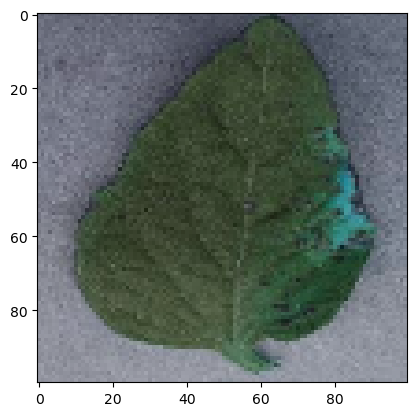

In [19]:
plt.imshow(Data[1][0])#IMAGE SHWING CODE

In [20]:
len(Data)

10000

In [21]:
len(Data[1][0])

100

In [13]:
Data[7872][1]

7

In [23]:
import random #for shuffle
random.shuffle(Data)

In [24]:
F=[]
T=[]
for i,j in Data:#FOR SEPERATING FEATURES AND TARGETS
    F.append(i)
    T.append(j)

In [25]:
len(F)

10000

In [26]:
T

[8,
 9,
 6,
 0,
 4,
 7,
 8,
 3,
 4,
 0,
 7,
 4,
 5,
 0,
 1,
 0,
 9,
 1,
 6,
 6,
 9,
 8,
 0,
 8,
 2,
 9,
 0,
 3,
 7,
 5,
 6,
 2,
 4,
 6,
 6,
 1,
 0,
 9,
 9,
 5,
 4,
 6,
 1,
 7,
 2,
 3,
 9,
 5,
 3,
 3,
 1,
 8,
 9,
 3,
 2,
 4,
 6,
 9,
 1,
 5,
 7,
 8,
 8,
 1,
 3,
 5,
 9,
 0,
 4,
 5,
 5,
 8,
 0,
 7,
 8,
 2,
 7,
 7,
 3,
 1,
 7,
 5,
 3,
 8,
 3,
 1,
 9,
 4,
 0,
 1,
 3,
 1,
 9,
 8,
 7,
 3,
 3,
 6,
 3,
 0,
 6,
 2,
 6,
 5,
 8,
 5,
 3,
 9,
 0,
 4,
 3,
 3,
 1,
 3,
 3,
 5,
 0,
 2,
 7,
 4,
 4,
 5,
 0,
 2,
 3,
 8,
 2,
 3,
 3,
 9,
 0,
 4,
 2,
 9,
 6,
 7,
 4,
 6,
 6,
 9,
 0,
 0,
 2,
 0,
 6,
 1,
 4,
 6,
 1,
 1,
 5,
 3,
 7,
 6,
 1,
 3,
 3,
 4,
 7,
 1,
 8,
 2,
 9,
 1,
 5,
 2,
 0,
 9,
 5,
 5,
 6,
 4,
 0,
 7,
 6,
 2,
 4,
 2,
 1,
 5,
 7,
 6,
 5,
 2,
 8,
 5,
 2,
 7,
 1,
 8,
 7,
 7,
 7,
 6,
 2,
 3,
 7,
 3,
 4,
 8,
 1,
 6,
 8,
 3,
 4,
 5,
 7,
 8,
 9,
 9,
 5,
 1,
 9,
 6,
 5,
 6,
 1,
 0,
 8,
 1,
 7,
 4,
 1,
 7,
 0,
 3,
 8,
 9,
 3,
 5,
 8,
 0,
 3,
 1,
 7,
 5,
 5,
 5,
 8,
 8,
 2,
 2,
 2,
 1,
 3,
 1,
 8,
 9,
 1,
 8,


In [27]:
T1=pd.get_dummies(T).replace({True:1,False:0}) # THESE TARGETS ARE NOMINAL SO GETTING DUMMIES FOR MAINTAING THE IN BETWEEN RELATION WITHOUT AFFECTING THE MODEL
T1

C:\Users\ARBAJ\AppData\Local\Temp\ipykernel_60228\4243940820.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  T1=pd.get_dummies(T).replace({True:1,False:0}) # THESE TARGETS ARE NOMINAL SO GETTING DUMMIES FOR MAINTAING THE IN BETWEEN RELATION WITHOUT AFFECTING THE MODEL


,0,1,2,3,4,5,6,7,8,9
0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,1,0,0
9996,0,0,0,1,0,0,0,0,0,0
9997,0,1,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,1


In [28]:
F=np.array(F)#FOR FASTER CALCULATION

In [29]:
F[1]

array([[[125, 130, 129],
        [126, 131, 130],
        [122, 127, 126],
        ...,
        [131, 136, 134],
        [133, 138, 136],
        [130, 135, 133]],

       [[126, 132, 130],
        [124, 129, 128],
        [128, 133, 132],
        ...,
        [138, 141, 139],
        [136, 139, 137],
        [134, 137, 135]],

       [[131, 136, 136],
        [125, 130, 129],
        [124, 129, 128],
        ...,
        [135, 136, 134],
        [133, 134, 132],
        [134, 135, 133]],

       ...,

       [[146, 153, 151],
        [147, 153, 152],
        [144, 150, 149],
        ...,
        [141, 144, 142],
        [140, 143, 141],
        [139, 142, 140]],

       [[137, 143, 142],
        [140, 146, 145],
        [145, 151, 150],
        ...,
        [141, 144, 142],
        [140, 143, 141],
        [139, 143, 140]],

       [[147, 153, 152],
        [148, 154, 153],
        [147, 153, 152],
        ...,
        [137, 140, 138],
        [136, 139, 137],
        [136, 138, 136]]

In [30]:
F1=F/255 #FOR MINMAX SCALER

In [31]:
F[1]#FIRST IMAGE WITHOUT MINMAX

array([[[125, 130, 129],
        [126, 131, 130],
        [122, 127, 126],
        ...,
        [131, 136, 134],
        [133, 138, 136],
        [130, 135, 133]],

       [[126, 132, 130],
        [124, 129, 128],
        [128, 133, 132],
        ...,
        [138, 141, 139],
        [136, 139, 137],
        [134, 137, 135]],

       [[131, 136, 136],
        [125, 130, 129],
        [124, 129, 128],
        ...,
        [135, 136, 134],
        [133, 134, 132],
        [134, 135, 133]],

       ...,

       [[146, 153, 151],
        [147, 153, 152],
        [144, 150, 149],
        ...,
        [141, 144, 142],
        [140, 143, 141],
        [139, 142, 140]],

       [[137, 143, 142],
        [140, 146, 145],
        [145, 151, 150],
        ...,
        [141, 144, 142],
        [140, 143, 141],
        [139, 143, 140]],

       [[147, 153, 152],
        [148, 154, 153],
        [147, 153, 152],
        ...,
        [137, 140, 138],
        [136, 139, 137],
        [136, 138, 136]]

In [32]:
F1[1]#FIRST IMAGE AFTER MINMAX

array([[[0.49019608, 0.50980392, 0.50588235],
        [0.49411765, 0.51372549, 0.50980392],
        [0.47843137, 0.49803922, 0.49411765],
        ...,
        [0.51372549, 0.53333333, 0.5254902 ],
        [0.52156863, 0.54117647, 0.53333333],
        [0.50980392, 0.52941176, 0.52156863]],

       [[0.49411765, 0.51764706, 0.50980392],
        [0.48627451, 0.50588235, 0.50196078],
        [0.50196078, 0.52156863, 0.51764706],
        ...,
        [0.54117647, 0.55294118, 0.54509804],
        [0.53333333, 0.54509804, 0.5372549 ],
        [0.5254902 , 0.5372549 , 0.52941176]],

       [[0.51372549, 0.53333333, 0.53333333],
        [0.49019608, 0.50980392, 0.50588235],
        [0.48627451, 0.50588235, 0.50196078],
        ...,
        [0.52941176, 0.53333333, 0.5254902 ],
        [0.52156863, 0.5254902 , 0.51764706],
        [0.5254902 , 0.52941176, 0.52156863]],

       ...,

       [[0.57254902, 0.6       , 0.59215686],
        [0.57647059, 0.6       , 0.59607843],
        [0.56470588, 0

In [33]:
F1.shape#10000 IMAGES HAVING WIDTH OF 150 ,HEIGHT OF 150 AND 3 RGB CHANNEL

(10000, 100, 100, 3)

In [34]:
T1.shape #TARGET VARIABLE SHAPE

(10000, 10)

In [35]:
T=np.array(T)

## MODEL BUILDING

In [36]:
model=Sequential()
#DATA AUGMENTATION
model.add(layers.experimental.preprocessing.RandomFlip('horizontal'))
model.add(layers.experimental.preprocessing.RandomRotation(0.1))
model.add(layers.experimental.preprocessing.RandomZoom(0.1))
model.add(layers.experimental.preprocessing.RandomContrast(0.1))


model.add(  Conv2D(  120,   (5,5),  activation='relu')  )#120 IS FILTER COUNT ,(5*5) IS FILTER SIZE
model.add(  MaxPooling2D(  (2,2)  ,strides=(1,1)))#(2*2)IS THE MAXPOOLING MATRIX

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2),strides=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2),strides=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2),strides=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2),strides=(2,2)))


model.add(Flatten())

model.add(Dense(60,input_shape=(100,100,3),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(1,activation='softmax'))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'],run_eagerly=True)

In [37]:
model.fit(F1,T, epochs=1, validation_split=0.15, batch_size=12)

MemoryError: Unable to allocate 973. MiB for an array with shape (8500, 100, 100, 3) and data type float32

In [ ]:
img_path = r"C:\Users\ARBAJ\Downloads\archive (10)\tomato\val\Tomato___Spider_mites Two-spotted_spider_mite\0a2b122a-0f23-4c92-8b7a-21b274dffbe5___Com.G_SpM_FL 9350.JPG"
img = cv.imread(img_path,)

img_resized = cv.resize(img, (150, 150))
img_resized=img_resized.reshape(1, 150, 150, 3)

plt.imshow(img,)
plt.show()

In [ ]:
prediction = model.predict(img_resized)
prediction

In [ ]:
dis[1]

In [ ]:
P1=r"C:\Users\ARBAJ\Downloads\archive (10)\tomato\val"

In [ ]:
Data1=[]
for i in dis:# ALL FOLDERS INSIDE PARENT PATH
    #print(i)
    A=os.path.join(P1,i) #FOR JOINING PATHS
    #print(A)
    
    
    
    for j in os.listdir(A):# FOR GETTING ALL CONTENT FROM FOLDER
        #print(j)
        B=os.path.join(A,j)#JOIN
        #print(B)
        img=cv.imread(B)#CONVERTING IMAGE TO PIXEL INTENSITY MATRIX
        C=cv.resize(img,(150,150))# RESIZING PIXEL INTENSITY MATRIX
        T=dis.index(i) #FOR GETTING TARGET VARIABLE
        Data1.append([C,T]) #TO STORE

In [ ]:
import random #for shuffle
random.shuffle(Data1)

In [ ]:
Data1[1]

In [ ]:
F1=[]
T1=[]#ACTUAL LABELS FOR TESTING
for i,j in Data1:#FOR SEPERATING FEATURES AND TARGETS
    F1.append(i)
    T1.append(j)

In [ ]:
T1

In [ ]:
F1=np.array(F1)
F1=F1/255 #FOR MINMAX SCALER

In [ ]:
pred=model.predict(F1)
pred

In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(T1,pred))

In [ ]:
print(classification_report(T1,pred))